# Radioligand Therapy (RLT) Part 2: Modeling how radionuclide half-life affects tumor targeting and off-target emissions using a semi-mechanistic PK/PD approach 
## Exploring Precision Cancer Therapies

tags: [pharmacology, drug discovery, radioligand therapy, cancer therapies]

![image](https://drive.google.com/thumbnail?id=1csETvK4s2kjEEXKL-RkYsKqv73xSGK9r&sz=w1200)


Hello, and welcome!

This post is a follow-up to my [previous post on radioligand therapy (RLT)](https://blakeaw.github.io/2024-09-22-radioligand-therapy-1/) and the second post in my new <i>Exploring Precision Cancer Therapies</i> series. Here, we'll take an exploratory modeling approach to better understand critical factors in RLT using a semi-mechanistic PK/PD model. In particular, I thought it would be interesting to use the RLT model to evaluate the impact of the decay half-life of the RLT's radionuclide on the tumor-targeted and off-target emissions delivered by a dose of RLT. So, let's jump in. 

______

## Contents

1. A semi-mechanistic PK/PD model of RLT
2. Setting Up Your Python Environment
3. How does radionuclide half-life impact the amount of tumor-targeted radioactive emissions?
    1. Setup
    2. Simulations
    3. Results
4. How does radionuclide half-life impact off-target emissions?
5. Concluding Thoughts
6. Acknowledgments/Disclosures

______

## A semi-mechanistic PK/PD model of RLT

For our RLT model, we will use a three-compartment semi-mechanistic PK/PD model. The three compartments consist of a central compartment, one peripheral compartment, and a compartment representing the tumor, which the RLT targets. 

Regarding PK processes, the RLT can be distributed and re-distributed between the central<->peripheral and central<->tumor with linear elimination from the central compartment to approximate renal clearance. It is assumed that distribution to the tumor compartment is hindered relative to healthy tissue, so the nominal rate constants are lower than those for the peripheral compartment distribution.

The model's mechanistic components include the target biomarker's expression in the tumor compartment, which the RLT can reversibly bind. After binding, the RLT-Biomarker complex can be absorbed into cells, approximating the endocytosis process. Then, the RLT and biomarker irreversibly unbind, and the biomarker is then recycled back to cell surfaces, where it can continue binding the RLT. Once taken up, the RLT is assumed to remain internalized.

The more RLT-specific part of the model is the radioactive decay of the RLT, generating a radioactive emission, after which the RLT becomes inactive. However, the inactive RLT still distributes/re-distributes and can bind the biomarker in the tumor compartment, acting as a competitive inhibitor. Since we are considering a generic model of RLT with a generic representation of the emitted radiation ('emissions'), we will use the amount of these emissions as our proxy for the potential level of cytotoxicity the RLT can deliver to the target tumor. In principle, the [type of radiation](https://www.epa.gov/radiation/radiation-basics#ioniandnonioni) emitted and its energy are also essential factors we won't consider here.   

Here is the model schematic:

![image](https://github.com/Borealis-BioModeling/radioligand-therapy-model/blob/921f98b1d0e1cf1255475d35a08a9db2842cd317/img/model-schematic_RLT.png?raw=true)

**Some Additional Notes About The Model:** The ovals representing a cancer cell and an endosome inside a cancer cell are illustrative and do not represent separate compartments in the model; the associated biomarkers are modeled as being distributed uniformly throughout the TUMOR compartment (well-mixed approximation). The RLT reversibly binds the biomarker at the cell surface, after which the complex can be internalized. After internalization, the RLT irreversibly unbinds the biomarker, which can be recycled back to the cell surface. I've also simplified the drug administration in the model to an I.V. bolus dose rather than a more realistic I.V. infusion.  

Although it is a generic model, and I've encoded it with nominal default parameter values, we can use it to explore how various parameters affect RLT delivery and the levels of radioactive emissions near the target cancer cells.     

A pre-encoded version of the model is available here: ([github.com/Borealis-BioModeling/radioligand-therapy-model](https://github.com/Borealis-BioModeling/radioligand-therapy-model)). You will install it in the following __Setting Up Your Python Environment__ section. 

______

## Setting Up Your Python Environment



I recommend using a `conda` environment so you can more easily install PySB while managing other dependencies. These days, I prefer to use [miniconda](https://docs.conda.io/projects/miniconda/en/latest/) and then install what I need in new environments. If you don't want to use `conda,` you should still be able to make some adjustments to the following steps. 

The main packages we need are [PySB](https://pysb.org/) and [pysb-pkpd](https://github.com/blakeaw/pysb-pkpd):

**PySB**
```
conda install -c alubbock pysb
```
Other options for installation are available at the [PySB Download Page](https://pysb.org/download.html)

**pysb-pkpd** - (currently version 0.3.3)
```
pip install git+https://github.com/blakeaw/pysb-pkpd@v0.3.3
```

**pysb-units** - (currently version 0.4.0)
```
pip install git+https://github.com/Borealis-BioModeling/pysb-units@v0.4.0
```

**rltmod** - (the RLT model)
```
pip install git+https://github.com/Borealis-BioModeling/radioligand-therapy-model@rlt-blog-post
```

I also recommend going ahead and installing [Cython](https://cython.org/). PySB uses it to compile ODEs and improve the speed of the `ScipyOdeSimulator`, which we will be using here:

```
conda install cython
```

To make the plots demonstrated here, be sure you have [matplotlib](https://matplotlib.org/):
```
conda install matplotlib
```
You can swap out the plotting commands if you prefer some other plotting library. 

Lastly, for a more interactive and dynamic experience, I'd recommend following along and executing the examples in your own computational notebook. I like [JupyterLab](https://jupyter.org/):
```
pip install jupyterlab
```
However, you could also try something like [Google Colab](https://colab.google/) (although dependencies may be a little trickier).

______

## How does radionuclide half-life impact the amount of tumor-targeted radioactive emissions?

In this section, we will explore how the radionuclide's [radioactive decay](https://www.epa.gov/radiation/radioactive-decay) half-life impacts the amount of targeted [ionizing radiation](https://www.epa.gov/radiation/radiation-basics#ioniandnonioni) emissions delivered to cancerous tissue. Since RLTs are particularly sensitive to the time it takes to distribute the RLT to clinics and then administer them to patients post-production (discussed in my [previous post](https://blakeaw.github.io/2024-09-22-radioligand-therapy-1/)), we will also consider how this in combination with the radionuclide's decay half-life ultimately impacts tumor-targeted emissions.

The number of emissions will be our proxy for an RLT's potential cytotoxic damage to cancer cells and its ultimate therapeutic effect. In this context, we will define targeted radioactive emissions as any produced in the `TUMOR` compartment of our RLT model.

Although we are not accounting for it here, the significance of the [type of radiation](https://www.epa.gov/radiation/radiation-basics#ioniandnonioni) emitted and its energy should be kept in mind when interpreting the results.   

### Setup

First, let's import all the libraries we'll use:

In [1]:
import numpy as np
from scipy.constants import N_A
import matplotlib.pyplot as plt
import pysb.pkpd as pkpd

Then, we can import the model:

In [2]:
from rltmod import model

Next, let's define the radionuclide half-lives we want to consider. We will use those defined in the table under __Some Current Challenges of RLTs__ of the [RLT Part I post](https://blakeaw.github.io/2024-09-22-radioligand-therapy-1/):

| Radioisotope | Half-life |
| ------------ | --------- |
| Indium-111   | [[2.81 days](https://www.accessdata.fda.gov/drugsatfda_docs/label/2002/ibriide021902LB.pdf)] |
| Yttrium-90   | [[2.67 days](https://www.accessdata.fda.gov/drugsatfda_docs/label/2002/ibriide021902LB.pdf)]         |
| Iodine-131   | [[8.201 days](https://www.accessdata.fda.gov/drugsatfda_docs/label/2018/209607s000lbl.pdf)] |
| Lutetium-177 | [[6.647 days](https://www.accessdata.fda.gov/drugsatfda_docs/label/2022/215833s000lbl.pdf)] |
| | |

We will assume that we augment the decay half-life without affecting RLT's distribution properties or affinity for the target biomarker. Now, let's define the half-lives:

In [3]:
radionuclides = ['Yttrium-90', 'Indium-111', 'Lutetium-177', 'Iodine-131']
# Define in days:
halflives_day = np.array([2.67, 2.81, 6.647, 8.201]) # days
# Convert to hours:
halflives_hr = halflives_day * 24 # hr

Let's go ahead and define the amount of RLT we want to consider. We will assume that the same amount of RLT is produced for each radionuclide (i.e., different half-lives) and then factor in the decay into the amounts of active versus inactive RLT administered at the various logistical delay times. Let's assume 100 nanomoles (nmol) as a reasonable value:

In [4]:
rlt_amount = 100. # nmol

Next, let's consider the logistical delay times. As an example of production time, Novartis can go from enriched radioisotopes to the final RLT product in about three days (72 hours) as reported in [this CNBC article](https://www.cnbc.com/2023/02/11/radioligand-cancer-therapy-forces-manufacturers-to-race-the-clock.html). However, after that, the drug still needs to be delivered and administered to patients. 

So, for our analysis, let's consider the delay time to be the time it takes for the final RLT product to be delivered and then administered to a patient; we won't include the production time, even though technically, the radioisotopes begin to decay after the enrichment process. Effectively, we will assume that the final purified and quality-controlled RLT is active, and its radioactivity only decays significantly after production. 

At the low end of delay times, we will consider the ideal case where the RLT can be immediately administered to patients with no delay (i.e., zero) and a relatively fast time of eight hours. 
Now, considering that Novartis' Lutathera and Pluvicto RLTs have shelf lives [are reported](https://www.cnbc.com/2023/02/11/radioligand-cancer-therapy-forces-manufacturers-to-race-the-clock.html) to be three and five days post-production, respectively, we could reasonably expect that the delay time would probably not exceed a week, even for Iodine-131, which has the most prolonged half-life of about eight days. So, we will use seven days as our maximum logistical delay time and consider one-day intervals otherwise.  

In [5]:
t_delays_day = np.array([0, 8/24, 1, 2, 3, 4, 5, 6, 7]) # days
t_delays_hr = t_delays_day * 24 # hr
t_delays_hr

array([  0.,   8.,  24.,  48.,  72.,  96., 120., 144., 168.])

Now, let's define the simulation time for our model. We will simulate six weeks, the interval between consecutive Pluvicto and Lutathera RLT treatments, which is much longer than any of the half-lives we are considering. However, it's worth pointing out that the model does not account for changes in the tumor with RLT treatment (e.g., reduction in tumor size). 

In [6]:
total_time_hrs = 6 * 7 * 24 # hrs

Next, let's set the time interval for our simulation time course:

In [7]:
delta_t_hrs = 1 / 360 # every 10 seconds

And, then we can compute the number of time points in our trajectories:

In [8]:
n_time_points = int(np.round(total_time_hrs / delta_t_hrs, 0)) + 1
n_time_points

362881

Then, we'll use that with NumPy's `linspace` function to generate the time span for our simulation:

In [9]:
tspan_hr = np.linspace(0, total_time_hrs, n_time_points, endpoint=True)
len(tspan_hr)

362881

In [10]:
# Conversions to different time units
tspan_sec = tspan_hr * 3600 # sec
tspan_days = tspan_hr / 24 # days

### Simulations

Finally, we'll run all the simulations, which includes each combination of RLT halflife and logistical time delay. We'll use a couple of for loops and store the simualtion outputs in a dictionary:

Text(0.5, 0, 'Time (days)')

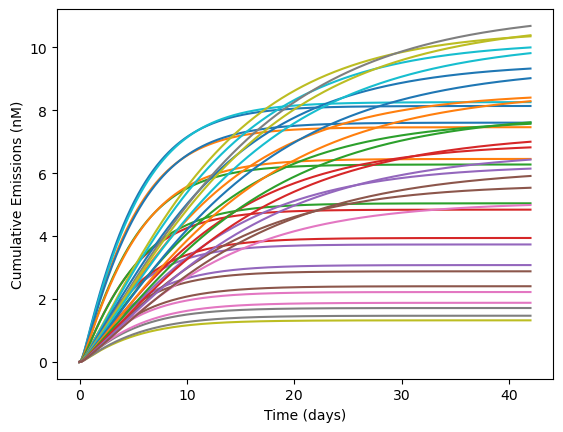

In [11]:
sim_outputs = dict()
for rlt_halflife_hr in halflives_hr:
    sim_outputs[rlt_halflife_hr] = list()
    for t_delay in t_delays_hr:
        #print(f"Doing half-life {rlt_halflife_hr} and logistical delay {t_delay}")
        # Determine the current radioactive decay rate constant
        k_decay = np.log(2) / rlt_halflife_hr # 1/hr
        # Set the initial amount (dose) of active RLT:
        model.parameters['dose_RLT_CENTRAL'].value = rlt_amount * np.exp(-k_decay * t_delay)
        # and the inactive RLT:
        model.parameters['dose_RLT_decay_CENTRAL'].value = rlt_amount * (1 - np.exp(-k_decay * t_delay))
        # Set the RLT halflife:
        model.parameters['rlt_halflife'].value = rlt_halflife_hr
        # Simulate the model and collect the output.
        sim_out = pkpd.simulate(model, tspan_hr)
        sim_outputs[rlt_halflife_hr].append(sim_out)
        # Plot the cumulative emissions so we can get a quick comparison of the
        # curves:
        cumulative_emissions = sim_out['obs_Emission_TUMOR'] 
        plt.plot(tspan_days, cumulative_emissions)

plt.ylabel('Cumulative Emissions (nM)')
plt.xlabel('Time (days)')

### Results

Now, let's plot the final cumulative targeted emissions from the TUMOR compartment:

(0.0, 12.0)

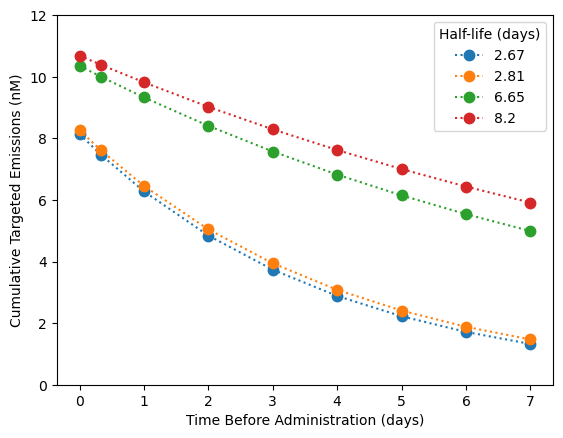

In [15]:
for i, halflife in enumerate(sim_outputs):
    sim_outs = sim_outputs[halflife]
    t_emissions = []
    for sim_out in sim_outs:
        t_emissions.append(sim_out["obs_Emission_TUMOR"][-1])
    plt.plot(t_delays_day, t_emissions, label=np.round(halflife/24, 2), linestyle=':', marker='o', markersize=7.5)
plt.ylabel('Cumulative Targeted Emissions (nM)')
plt.xlabel('Time Before Administration (days)')
plt.legend(loc=0, title='Half-life (days)')
plt.ylim((0,12))

The model predicts that with everything else equal (distribution, elimination, binding, uptake, etc.), an RLT with a longer half-life consistently delivers more radioactive emissions to the targeted tumor. As the delay between production and eventual administration of the RLT increases, the amount of tumor-targeted emissions decreases for all half-lives. Still, the difference between the longer and shorter half-lives increases with time before administration. This makes sense because the radioactivity of the initial dose decreases over time for all the radionuclides, but the effect is more dramatic with shorter half-life isotopes.  

It's interesting to note that with zero time before administration, where there has been no decay of the initial dose, and so the amount of active RLT is the same across the different half-lives, the RLTs with longer radionuclide half-lives still deliver more targeted emissions. This suggests that with a longer half-life, more of the radioactive RLT can be internalized into tumor cells before decaying. We can examine the dynamics to explore this a bit more.

First, let's look at the total radioactive RLT in each compartment:

Text(0.02, 0.5, 'Radioactive RLT (nM)')

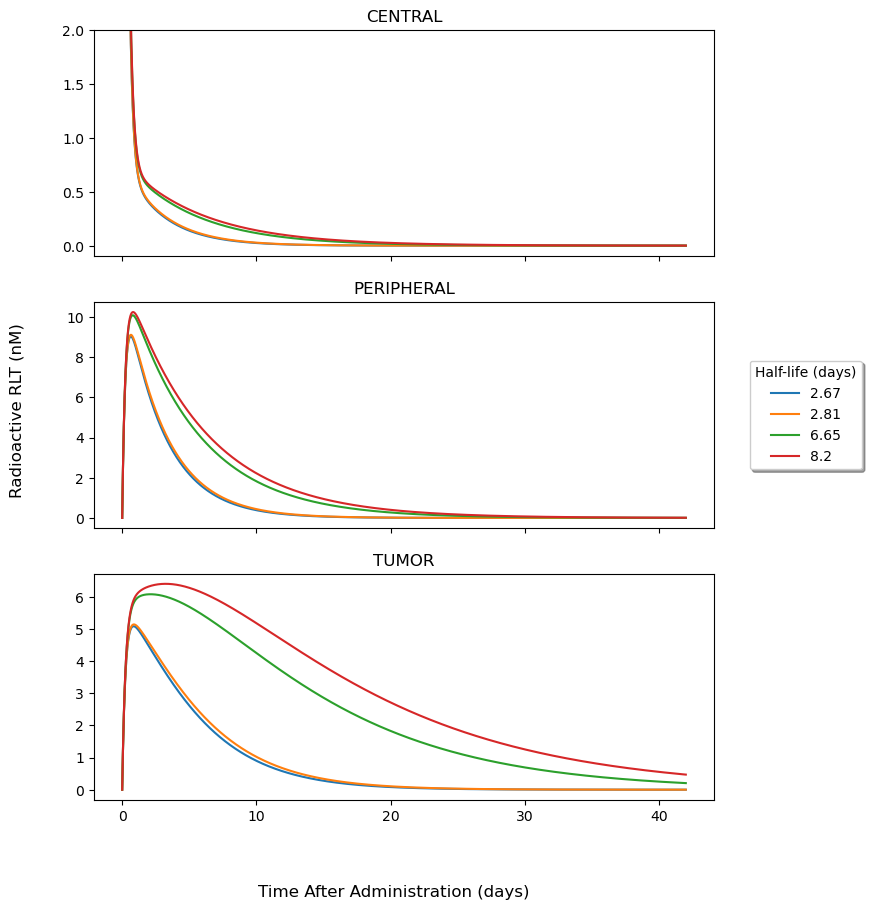

In [13]:
nplot = 3
fig, axs = plt.subplots(3, sharex=True)
for halflife in sim_outputs:
    sim_outs = sim_outputs[halflife][0]     
    axs[0].plot(tspan_days, sim_outs['obs_RLT_CENTRAL_active'], label=np.round(halflife/24, 2))
    axs[1].plot(tspan_days, sim_outs['obs_RLT_PERIPHERAL_active'], label=np.round(halflife/24, 2))
    axs[2].plot(tspan_days, sim_outs['obs_RLT_TUMOR_active'], label=np.round(halflife/24, 2))
axs[0].set_title("CENTRAL")
axs[1].set_title("PERIPHERAL")
axs[2].set_title("TUMOR")
axs[1].legend(loc='center right',
              title='Half-life (days)',
              bbox_to_anchor=(1.25, 0.5),
              fancybox=True, shadow=True)
axs[0].set_ylim((-0.1, 2))
fig.set_size_inches(8, 10)
fig.supxlabel('Time After Administration (days)')
fig.supylabel('Radioactive RLT (nM)')

We can see that the difference in the CENTRAL compartment isn't that dramatic, but the longer half-life RLTs have more radioactive molecules circulating for longer. In turn, the amount of radioactive RLT delivered to the PERIPHERAL and TUMOR compartments by longer-lived RLTs is more significant, as exhibited by a more prominent peak concentration and a larger area under the curve. The greater concentration and prolonged exposure ultimately allow longer-lived RLTs to deliver more radioactive emissions to the TUMOR compartment. The trade-off, however, is that there is also more prolonged radioactivity in circulation and the peripheral tissues. 

This brings us to our next question: what about off-target emissions?

------

## How does radionuclide half-life impact off-target emissions?

Next, we will consider the off-target emissions for each modeled half-life. This is our proxy for an RLT's potential to damage healthy cells and tissue, which could cause unwanted side effects. 

In this context, we define the off-target radioactive emissions as any emissions generated in the `CENTRAL` and `PERIPHERAL` compartments. 

Let's start by examining all the cumulative off-target emissions:

(0.0, 15.0)

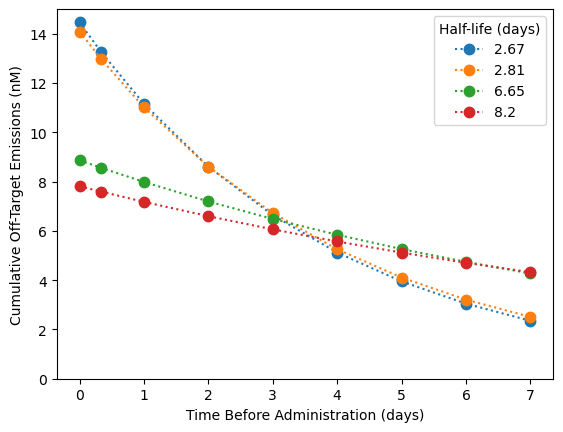

In [16]:
for i, halflife in enumerate(sim_outputs):
    sim_outs = sim_outputs[halflife]
    t_emissions = []
    for sim_out in sim_outs:
        t_emissions.append(sim_out["obs_Emission_off_target"][-1])
    plt.plot(t_delays_day, t_emissions, label=np.round(halflife/24, 2), linestyle=':', marker='o', markersize=7.5)
plt.ylabel('Cumulative Off-Target Emissions (nM)')
plt.xlabel('Time Before Administration (days)')
plt.legend(loc=0, title='Half-life (days)')
plt.ylim((0,15))

Interestingly, we can see that within a four-day time window before administration, the longer-lived RLTs produce fewer off-target emissions. So, even though the longer-lived RLTs have higher levels and more prolonged exposure to the radioactive molecule, fewer RLTs end up decaying and generating emissions before being cleared from the CENTRAL and PERIPHERAL compartments. Only at extended timeframes of 4 days or later do the RLTs with shorter half-lives generate fewer off-target emissions than the longer-lived variants. However, the longer-lived RLTs deliver roughly twice as much on-target emissions at that point, so this model suggests you would still get <i>more bang for your buck</i> with the longer radionuclide half-lives. 

## Closing Thoughts

RLTs are an intriguing approach to precision cancer therapy that combines biomarker targeting with radioactivity to selectively deliver cytotoxic radiation to cancer cells. In this post, we introduced a semi-mechanistic PK/PD model of a generic radioligand therapy (RLT). We used this model to explore how changing the RLT's radioactive decay half-life affects the targeted and off-target emissions levels it generates. We also varied the time before dose administration, during which the RLT still undergoes radioactive decay, ultimately leading to loss of potency. This problem presents a unique logistical challenge for RLT since it requires a very compressed timeline from production to patient. 

A fascinating result we found was that longer half-lives corresponded with more targeted emissions to the model's tumor compartment while, in most cases, yielding fewer off-target emissions. This suggests that RLTs utilizing a radionuclide with a longer half-life may provide greater cancer-targeting with a more potent anti-tumor effect and fewer side effects, at least when cellular internalization of the RLT is high and rapid in the tumor. However, the longer decay half-lives also corresponded with a longer window of elevated radioactivity in circulation and peripheral tissues. This means a patient would be radioactive longer than when a shorter half-life radionuclide is used. 

Now, let's touch on the limitations of this analysis. We did not consider how differences in critical processes like distribution, biomarker binding, and cellular uptake amongst RLTs alter the observed dynamics and cumulative emissions. We also didn't factor in the type of radiation or its emission energy generated by different radionuclides, another vital element in the overall cytotoxicity of an RLT. Another potential limitation of this analysis is that the model uses a nominal set of parameters. Although I tried to pick what seemed to be reasonable values, a more robust approach likely would be to calibrate the model to experimental time-activity curves first and then execute additional model exploration and analysis using the calibrated model. Calibrating the model to experimental data first would also highlight how well the model can fit that data, shedding additional insight into the accuracy of the model's compartmental structure and mechanistic elements. Perhaps these issues are worth exploring in later posts. 

If you're interested, I'd encourage you to take the RLT model here, adapt it as needed, and perform your own analyses! If you do, be sure to let me know what you find.   

Thanks for reading, and have a nice day! Do you feel like these results make sense? Feel free to message me and let me know what you think or if you have any questions or want to discuss. I'm also open to feedback and suggestions for future posts, so if there is something you think I should cover, let me know! I'm considering additional posts on RLT before moving on to the subsequent precision cancer therapy, so drop me a line if you are still interested in exploring RLT further. You can contact me on [LinkedIn](https://www.linkedin.com/in/blakewilson3/).

Lastly, please share this post with anyone else who might be interested. It is a massive help to me, as it increases the blog's visibility and can help more people discover my work. Also, keep an eye out for future posts.

Until next time -- Blake

## Acknowledgements/Disclosures

[Grammarly](https://app.grammarly.com/) was used for proofreading and editing. 

Schematics were created using [Inkscape](https://inkscape.org/) with some additional image editing with [GIMP](https://www.gimp.org/).

------
------

Like this content? You can follow this blog and get updated about new posts via my blog's RSS/Atom Feed.

------
------

If you are so inclined, you can also be a financial supporter of my open-source work through Ko-fi:

[![ko-fi](https://ko-fi.com/img/githubbutton_sm.svg)](https://ko-fi.com/J3J4ZUCVU)

------
------

**Other related posts you might like:**

[Radioligand Therapy (RLT) Part 1 - An Overview](https://blakeaw.github.io/2024-09-22-radioligand-therapy-1/)

[Modeling Drug Dynamics using Programmatic PK/PD Models in Python](https://blakeaw.github.io/2023-10-23-pysb-pkpd/)

[Introducing Aurora PK/PD! An Open Web App for Pharmacological Modeling and Analysis](https://blakeaw.github.io/2024-07-29-aurora-pkpd-announcement/)

------